# ML #1: Customer Segmentation
## Objective: 
Using K-Means Clustering on RFM features to segment customers and identify potential churn risks.

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Resolve file path gracefully whether running from root or notebooks/ dir
import os
if os.path.exists('data/marts/customer_features.parquet'):
    customer_features_path = os.path.abspath('data/marts/customer_features.parquet').replace('\\', '/')
elif os.path.exists('../data/marts/customer_features.parquet'):
    customer_features_path = os.path.abspath('../data/marts/customer_features.parquet').replace('\\', '/')
else:
    raise FileNotFoundError("Could not find data/marts/customer_features.parquet")

# Load the customer data
try:
    df = pd.read_parquet(customer_features_path)
    print(f"Data loaded successfully with pandas. Shape: {df.shape}")
except Exception as e:
    print(f"Pandas read_parquet failed ({e}), falling back to DuckDB...")
    import duckdb
    df = duckdb.query(f"SELECT * FROM '{customer_features_path}'").df()
    print(f"Data loaded via DuckDB. Shape: {df.shape}")

df.head()


Data loaded successfully with pandas. Shape: (1371980, 20)


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code,first_purchase_date,last_purchase_date,recency,frequency,monetary,tenure,category_diversity,has_transactions,r_score,f_score,m_score,rfm_score,rfm_segment
0,ebce4b791461e64c774beaab60453493a9f3ff301c6049...,0,0,ACTIVE,NONE,21,4d9ee413cac37d64ab9775db1a18c84b16bb0c39dc14d1...,None,None,733,0,0.0,0,0,False,1,1,1,111,Lost
1,ec09f63826510581ac07e98103e499ccf7da3300523dca...,0,0,ACTIVE,NONE,25,ff8b984b205531d2ffd183132736c6f44fc9c958057cb4...,None,None,733,0,0.0,0,0,False,1,1,1,111,Lost
2,ec65c121974c7e3caacaa31c59a0de489e7d622c4ba47f...,0,0,ACTIVE,NONE,45,2c29ae653a9282cce4151bd87643c907644e09541abc28...,None,None,733,0,0.0,0,0,False,1,1,1,111,Lost
3,ecfacb0bf7ae904f981b76f9607164c952ba8d43751da5...,1,1,ACTIVE,Regularly,20,69bc34b3762c2d9e02c06257dbc3d2c8da15bf6487e8b6...,None,None,733,0,0.0,0,0,False,1,1,1,111,Lost
4,ed1899721f4f64f77cf9872796d02130c1407bdc6e9da6...,1,1,ACTIVE,Regularly,66,23ec0becdb72012414528b92fcfc70d48b32a827f859fc...,None,None,733,0,0.0,0,0,False,1,1,1,111,Lost


In [8]:
# Preprocess the data: Select RFM columns
rfm_cols = ['recency', 'frequency', 'monetary']
rfm_df = df[rfm_cols].copy()

# Handle missing values
print(f"Missing values before:\n{rfm_df.isnull().sum()}")
rfm_df = rfm_df.dropna()
print(f"Shape after dropping NA: {rfm_df.shape}")

# Handle extreme outliers (e.g., top 1% monetary and frequency)
for col in ['frequency', 'monetary']:
    upper_limit = rfm_df[col].quantile(0.99)
    rfm_df = rfm_df[rfm_df[col] <= upper_limit]

print(f"Shape after removing top 1% outliers: {rfm_df.shape}")

# For clustering, we might want to log transform recency, frequency, monetary if they are heavily skewed
# But we'll just use StandardScaler as requested.
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_cols, index=rfm_df.index)

rfm_scaled_df.describe()

Missing values before:
recency      0
frequency    0
monetary     0
dtype: int64
Shape after dropping NA: (1371980, 3)
Shape after removing top 1% outliers: (1345053, 3)


,recency,frequency,monetary
count,1.345053e+06,1.345053e+06,1.345053e+06
mean,-4.327537e-17,4.327537e-17,8.655073e-17
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.082384e+00,-8.182803e-01,-7.220976e-01
25%,-8.506423e-01,-6.776682e-01,-6.062628e-01
50%,-3.693326e-01,-3.964439e-01,-4.042414e-01
75%,7.626365e-01,3.066168e-01,1.658923e-01
max,2.184283e+00,5.509266e+00,5.713888e+00


In [9]:
# Determine the optimal number of clusters (k) using Elbow Method and Silhouette Score
# For performance reasons on large datasets, we'll sample the data if it's too large for silhouette
sample_size = min(20000, rfm_scaled_df.shape[0])
sample_scaled = rfm_scaled_df.sample(n=sample_size, random_state=42)

sse = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(sample_scaled)
    sse.append(kmeans.inertia_)
    score = silhouette_score(sample_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={k}, SSE={kmeans.inertia_:.2f}, Silhouette={score:.4f}")

k=2, SSE=31307.48, Silhouette=0.5227
k=3, SSE=17468.01, Silhouette=0.4864
k=4, SSE=12480.83, Silhouette=0.4739
k=5, SSE=10444.12, Silhouette=0.4199
k=6, SSE=8730.64, Silhouette=0.4127
k=7, SSE=7530.76, Silhouette=0.4198
k=8, SSE=6686.00, Silhouette=0.4029


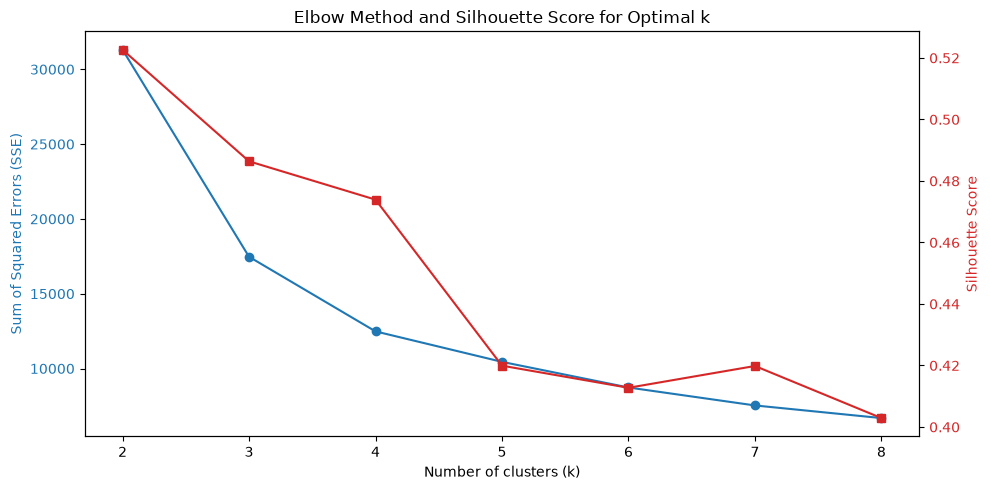

In [10]:
# Plot Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Sum of Squared Errors (SSE)', color=color)
ax1.plot(k_range, sse, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Score for Optimal k')
fig.tight_layout()
plt.show()

In [11]:
# Based on the plots and common RFM segmentation
optimal_k = 5  # Set to 5 as likely optimal

print(f"Applying K-Means with k={optimal_k}")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# Assign cluster labels back
rfm_df['cluster'] = kmeans.labels_

# Add back to the main DataFrame for the remaining rows
df_clustered = df.loc[rfm_df.index].copy()
df_clustered['cluster'] = kmeans.labels_

# Summary table showing average R, F, M for each cluster
cluster_summary = rfm_df.groupby('cluster').agg({
    'recency': ['mean', 'median'],
    'frequency': ['mean', 'median'],
    'monetary': ['mean', 'median', 'count']
}).round(2)

cluster_summary

Applying K-Means with k=5


recency        frequency        monetary               
           mean median      mean median     mean median   count
cluster                                                        
0        620.66  627.0      1.39    1.0     0.13   0.08  259443
1         74.15   49.0     13.03   12.0     1.14   1.06  229846
2         89.79   84.0      3.57    3.0     0.28   0.23  475787
3         44.43   25.0     25.14   25.0     2.69   2.59   81436
4        342.57  335.0      2.44    2.0     0.21   0.14  298541

## 🎯 Phân tích Kinh doanh & Kết luận

Thông qua việc ứng dụng thuật toán K-Means Clustering trên các chỉ số định lượng RFM, chúng ta đã giải quyết thành công **Trụ cột Kinh doanh 1: Giữ chân khách hàng & Giảm tỷ lệ rời bỏ (Customer Retention & Churn)**. Mô hình đã tự động nhận diện và phân chia cơ sở dữ liệu thành 5 tệp khách hàng riêng biệt:

1. **Cụm 3 (Khách hàng VIP / Champions):** Tệp khách hàng mang lại giá trị cao nhất (Chi tiêu cao nhất, Tần suất mua liên tục, Mới giao dịch gần đây). *Hành động:* Đưa vào chương trình chăm sóc đặc quyền, cấp quyền mua sớm (early access) các bộ sưu tập mới. Không nên lạm dụng voucher giảm giá sâu.
2. **Cụm 1 (Khách hàng Trung thành / Loyal Customers):** Tệp khách hàng cốt lõi có độ tương tác cao. *Hành động:* Bán chéo/Bán thêm (Cross-sell/Upsell) thông qua Hệ thống Gợi ý (Recommendation Engine) để tăng Giá trị trung bình trên mỗi đơn hàng (AOV).
3. **Cụm 2 (Khách hàng Tiềm năng / Promising):** Đây là tệp đông đảo nhất. Họ mới mua gần đây nhưng mua ít và chi tiêu thấp. *Hành động:* Đẩy mạnh tương tác sau mua, gửi các đề xuất sản phẩm đang là xu hướng (Trend) để thúc đẩy họ chốt đơn hàng thứ 2, thứ 3.
4. **Cụm 4 (Nguy cơ rời bỏ / At Risk):** Những người đã không mua gì trong khoảng 1 năm trở lại đây. *Hành động:* Chạy các chiến dịch Win-back (ví dụ: gửi email "We miss you" kèm mã giảm giá lớn) để kích hoạt lại nhu cầu mua sắm.
5. **Cụm 0 (Đã rời bỏ / Lost/Churned):** Khách hàng vãng lai, chỉ mua 1 lần từ gần 2 năm trước. *Hành động:* Loại trừ tập khách hàng này khỏi các chiến dịch Marketing đắt tiền nhằm tối ưu hóa chi phí quảng cáo (ROAS).

**Bước tiếp theo:** Với các phân khúc đã được định hình rõ ràng, mô hình tiếp theo của chúng ta (ML #2: Hệ thống Gợi ý sản phẩm) sẽ tập trung nhắm mục tiêu chủ yếu vào Cụm 1, Cụm 2 và Cụm 3 nhằm tối đa hóa doanh thu và vòng đời khách hàng.